## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from math import factorial
from scipy import stats as st

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
calls=pd.read_csv('./datasets/megaline_calls.csv')
internet=pd.read_csv('./datasets/megaline_internet.csv')
messages=pd.read_csv('./datasets/megaline_messages.csv')
plans=pd.read_csv('./datasets/megaline_plans.csv')
users=pd.read_csv('./datasets/megaline_users.csv')

## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
print(plans.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [4]:
# Imprime una muestra de los datos para las tarifas
print(plans.isna().sum())
print(plans.duplicated().sum())
print(plans.head())


messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64
0
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


#en este primer Data podemos observar que cuenta con dos entradas las cuales corresponden a los dos planes que se ofrecen, al buscar valores nulos o duplicados en este caso se puede buscar de manera manual por ser tan corto sin embargo tambien se buscaron mediante codigo y no se hayo ninguno, se puede concluir que el DF no tiene datos a corregir o cambiar

## Corregir datos

#En este caso no se observaron errores iniciales

## Enriquecer los datos

#No considero que este DF necesite enriquecerse de alguna manera

## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
print(users.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None


In [8]:
# Imprime una muestra de datos para usuarios
print(users.isna().sum())
print(users.duplicated().sum())
print(users['city'].unique())


user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64
0
['Atlanta-Sandy Springs-Roswell, GA MSA' 'Seattle-Tacoma-Bellevue, WA MSA'
 'Las Vegas-Henderson-Paradise, NV MSA' 'Tulsa, OK MSA'
 'Dallas-Fort Worth-Arlington, TX MSA'
 'San Francisco-Oakland-Berkeley, CA MSA' 'Grand Rapids-Kentwood, MI MSA'
 'Orlando-Kissimmee-Sanford, FL MSA'
 'San Jose-Sunnyvale-Santa Clara, CA MSA' 'Cleveland-Elyria, OH MSA'
 'Chicago-Naperville-Elgin, IL-IN-WI MSA' 'Knoxville, TN MSA'
 'New York-Newark-Jersey City, NY-NJ-PA MSA' 'Pittsburgh, PA MSA'
 'Fresno, CA MSA' 'Washington-Arlington-Alexandria, DC-VA-MD-WV MSA'
 'Indianapolis-Carmel-Anderson, IN MSA' 'Jacksonville, FL MSA'
 'Los Angeles-Long Beach-Anaheim, CA MSA'
 'Omaha-Council Bluffs, NE-IA MSA'
 'Houston-The Woodlands-Sugar Land, TX MSA'
 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA'
 'Tampa-St. Petersburg-Clearwater, FL MSA' 'Birmingham-Hoov

#En este DF podemos observar que hay 500 entradas, en las 8 columnas no hay valores duplicados, y en la unica columna en la cual encontramos valores ausentes es en la columna de abandono de servicio por ende se comprende que no esten llenos.

### Corregir los datos

#en este caso tras el analisis inicial no encontre ningun dato a corregir

### Enriquecer los datos

In [10]:
#en este DF considero que puedo agregar un pequeno cambio en la fecha para cambiar el tipo de dato de object a datatime y cambiar los datos ausentes por 'linea activa'
users['churn_date'] = users['churn_date'].fillna(value='Linea activa')
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')
print(users.head())
print(users.info())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan    churn_date  
0 2018-12-24  ultimate  Linea activa  
1 2018-08-13      surf  Linea activa  
2 2018-10-21      surf  Linea activa  
3 2018-01-28      surf  Linea activa  
4 2018-05-23      surf  Linea activa  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    obje

## Llamadas

In [11]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
print(calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None


In [12]:
# Imprime una muestra de datos para las llamadas
print(calls.isna().sum())
print(calls.duplicated().sum())
print(calls.head())

id           0
user_id      0
call_date    0
duration     0
dtype: int64
0
         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


#se observa en este DF que no hay datos ausentes ni duplicados a simple vista se puede considerar que la tabla esta limpia, se puede cambiar el timpo de dato de la fecha para que sea datetime pero quitando eso no considero que cuente con otro tipo de errores o cambios necesarios

### Corregir los datos

#considero que no hay datos a corregir en este DF

### Enriquecer los datos

In [14]:
#en este caso lo que haria para enriquecerlo y evitar pequenos errores seria cambiar el tipo de dato de la fecha de object a datatime.
calls['call_date'] = pd.to_datetime(calls['call_date'], format='%Y-%m-%d')
calls['month'] = calls['call_date'].dt.month
print(calls.head())
print(calls.info())

         id  user_id  call_date  duration  month
0   1000_93     1000 2018-12-27      8.52     12
1  1000_145     1000 2018-12-27     13.66     12
2  1000_247     1000 2018-12-27     14.48     12
3  1000_309     1000 2018-12-28      5.76     12
4  1000_380     1000 2018-12-30      4.22     12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
 4   month      137735 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 5.3+ MB
None


## Mensajes

In [15]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
print(messages.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None


In [16]:
# Imprime una muestra de datos para los mensajes
print(messages.isna().sum())
print(messages.duplicated().sum())
print(messages.head())

id              0
user_id         0
message_date    0
dtype: int64
0
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


#al igual que en los otros DF parece no haber errores lo unico apreciable es que la fecha que el dato es tipo object 

### Corregir los datos

#considero que no hay datos a corregir en este DF

### Enriquecer los datos

In [18]:
#para enriquecer y evitar posibles errores el unico cambio que haria seria cambiar las fechas de object a date
messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d')
messages['month'] = messages['message_date'].dt.month
print(messages.head())
print(messages.info())

         id  user_id message_date  month
0  1000_125     1000   2018-12-27     12
1  1000_160     1000   2018-12-31     12
2  1000_223     1000   2018-12-31     12
3  1000_251     1000   2018-12-27     12
4  1000_255     1000   2018-12-26     12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 2.3+ MB
None


## Internet

In [19]:
# Imprime la información general/resumida sobre el DataFrame de internet
print(internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None


In [20]:
# Imprime una muestra de datos para el tráfico de internet
print(internet.isna().sum())
print(internet.duplicated().sum())
print(internet.head())

id              0
user_id         0
session_date    0
mb_used         0
dtype: int64
0
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


#al igual que en los anteriores DF lo unico que detecto que se puede mejorar es el cambio de tipo de dato de date.

### Corregir los datos

#considero que no hay datos a corregir en este DF

### Enriquecer los datos

In [22]:
#para enriquecer y evitar posibles errores el unico cambio que haria seria cambiar las fechas de object a date
internet['session_date'] = pd.to_datetime(internet['session_date'], format='%Y-%m-%d')
internet['month'] = internet['session_date'].dt.month
print(internet.head())
print(internet.info())

         id  user_id session_date  mb_used  month
0   1000_13     1000   2018-12-29    89.86     12
1  1000_204     1000   2018-12-31     0.00     12
2  1000_379     1000   2018-12-28   660.40     12
3  1000_413     1000   2018-12-26   270.99     12
4  1000_442     1000   2018-12-27   880.22     12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 4.0+ MB
None


## Estudiar las condiciones de las tarifas

In [23]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
print(plans.info())
print(plans.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10      

## Agregar datos por usuario

In [ ]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
llamadas_por_usuario = calls.groupby(['user_id','month'])['id'].count().reset_index()
llamadas_por_usuario.rename(columns={'call_id': 'total_llamadas'}, inplace=True)
print(llamadas_por_usuario)

      user_id  month  id
0        1000     12  16
1        1001      8  27
2        1001      9  49
3        1001     10  65
4        1001     11  64
...       ...    ...  ..
2253     1498     12  39
2254     1499      9  41
2255     1499     10  53
2256     1499     11  45
2257     1499     12  65

[2258 rows x 3 columns]


In [ ]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
calls['duration'] = np.ceil(calls['duration'])
minutos = calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()
minutos.rename(columns={'minutes': 'minutos_totales'}, inplace=True)
print(minutos)

      user_id  month  duration
0        1000     12     124.0
1        1001      8     182.0
2        1001      9     315.0
3        1001     10     393.0
4        1001     11     426.0
...       ...    ...       ...
2253     1498     12     339.0
2254     1499      9     346.0
2255     1499     10     385.0
2256     1499     11     308.0
2257     1499     12     496.0

[2258 rows x 3 columns]


In [ ]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
total_messages = messages.groupby(['user_id', 'month'])['id'].count().reset_index()
total_messages.rename(columns={'message': 'mensajes_totales'}, inplace=True)
print(total_messages)

      user_id  month  id
0        1000     12  11
1        1001      8  30
2        1001      9  44
3        1001     10  53
4        1001     11  36
...       ...    ...  ..
1801     1496      9  21
1802     1496     10  18
1803     1496     11  13
1804     1496     12  11
1805     1497     12  50

[1806 rows x 3 columns]


In [ ]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
total_mb = internet.groupby(['user_id','month'])['mb_used'].sum().reset_index()
total_mb.rename(columns={'MB': 'mb_totales'}, inplace=True)
print(total_mb)

      user_id  month   mb_used
0        1000     12   1901.47
1        1001      8   6919.15
2        1001      9  13314.82
3        1001     10  22330.49
4        1001     11  18504.30
...       ...    ...       ...
2272     1498     12  23137.69
2273     1499      9  12984.76
2274     1499     10  19492.43
2275     1499     11  16813.83
2276     1499     12  22059.21

[2277 rows x 3 columns]


In [ ]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
important_information= llamadas_por_usuario.merge(minutos, on=['user_id','month'], how='outer')
important_information= important_information.merge(total_messages, on=['user_id','month'], how='outer')
important_information= important_information.merge(total_mb, on=['user_id','month'], how='outer')
important_information=important_information.rename(columns={'id_x':'user_calls','id_y':'user_messages'})
important_information= important_information.fillna(0)
print(important_information)

      user_id  month  user_calls  duration  user_messages   mb_used
0        1000     12        16.0     124.0           11.0   1901.47
1        1001      8        27.0     182.0           30.0   6919.15
2        1001      9        49.0     315.0           44.0  13314.82
3        1001     10        65.0     393.0           53.0  22330.49
4        1001     11        64.0     426.0           36.0  18504.30
...       ...    ...         ...       ...            ...       ...
2288     1349     12         0.0       0.0           61.0  13039.91
2289     1361      5         0.0       0.0            2.0   1519.69
2290     1482     10         0.0       0.0            2.0      0.00
2291     1108     12         0.0       0.0            0.0    233.17
2292     1311      6         0.0       0.0            0.0   1498.83

[2293 rows x 6 columns]


In [ ]:
# Añade la información de la tarifa
user_sumary=pd.merge(users[['user_id', 'plan']],important_information, on='user_id', how='left')
final_summary= pd.merge(user_sumary, plans, left_on='plan', right_on='plan_name', how='left')
print(final_summary)

      user_id      plan  month  user_calls  duration  user_messages   mb_used  \
0        1000  ultimate   12.0        16.0     124.0           11.0   1901.47   
1        1001      surf    8.0        27.0     182.0           30.0   6919.15   
2        1001      surf    9.0        49.0     315.0           44.0  13314.82   
3        1001      surf   10.0        65.0     393.0           53.0  22330.49   
4        1001      surf   11.0        64.0     426.0           36.0  18504.30   
...       ...       ...    ...         ...       ...            ...       ...   
2298     1498      surf   12.0        39.0     339.0            0.0  23137.69   
2299     1499      surf    9.0        41.0     346.0            0.0  12984.76   
2300     1499      surf   10.0        53.0     385.0            0.0  19492.43   
2301     1499      surf   11.0        45.0     308.0            0.0  16813.83   
2302     1499      surf   12.0        65.0     496.0            0.0  22059.21   

      messages_included  mb

In [ ]:
# Calcula el ingreso mensual para cada usuario
information=final_summary
information['extra_minutes'] = (information['duration'] - information['minutes_included']).clip(lower=0)
information['extra_messages'] = (information['user_messages'] - information['messages_included']).clip(lower=0)
information['extra_gb'] = np.ceil(information['mb_used']/1024 - information['mb_per_month_included']/1024).clip(lower=0)
information['extra_cost_minutes'] = information['extra_minutes'] * information['usd_per_minute']
information['extra_cost_messages'] = information['extra_messages'] * information['usd_per_message']
information['extra_cost_gb'] =np.ceil(information['extra_gb'] * information['usd_per_gb'])
information['total_monthly_revenue'] = information['usd_monthly_pay'] + information['extra_cost_minutes'] + information['extra_cost_messages'] + information['extra_cost_gb']
print(information.head())

   user_id      plan  month  user_calls  duration  user_messages   mb_used  \
0     1000  ultimate   12.0        16.0     124.0           11.0   1901.47   
1     1001      surf    8.0        27.0     182.0           30.0   6919.15   
2     1001      surf    9.0        49.0     315.0           44.0  13314.82   
3     1001      surf   10.0        65.0     393.0           53.0  22330.49   
4     1001      surf   11.0        64.0     426.0           36.0  18504.30   

   messages_included  mb_per_month_included  minutes_included  ...  \
0               1000                  30720              3000  ...   
1                 50                  15360               500  ...   
2                 50                  15360               500  ...   
3                 50                  15360               500  ...   
4                 50                  15360               500  ...   

   usd_per_message  usd_per_minute  plan_name  extra_minutes extra_messages  \
0             0.01            0

## Estudia el comportamiento de usuario

### Llamadas

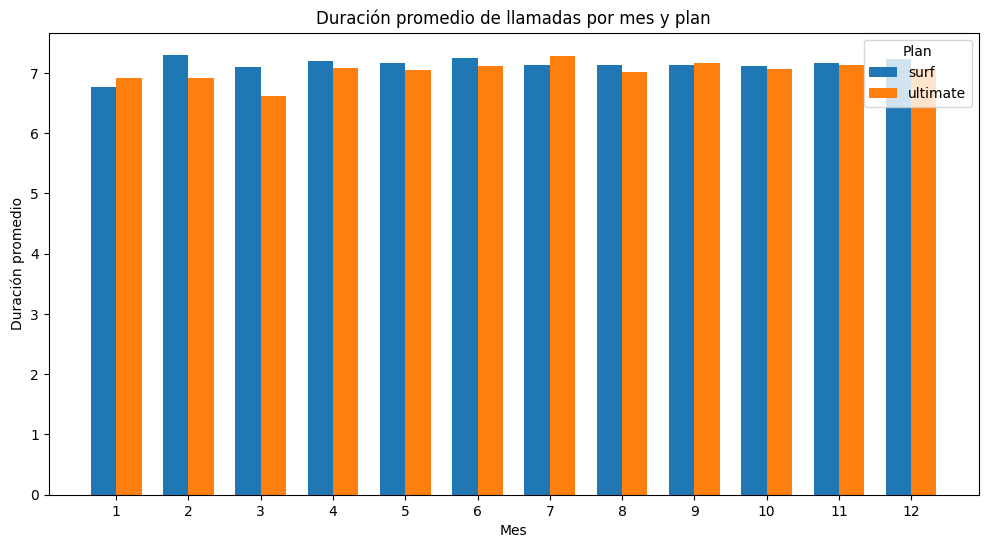

In [31]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
user_plan=users[['user_id','plan']]
new_calls=calls[['user_id','duration','month','id','call_date']]
user_calls_plan = user_plan.merge(new_calls, on='user_id', how='left')

mean_duration = user_calls_plan.groupby(['month','plan'])['duration'].mean()
mean_duration_df = mean_duration.reset_index()

months = mean_duration_df['month'].unique()
plans = mean_duration_df['plan'].unique()
x = np.arange(len(months))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))
for i, plan in enumerate(plans):
    plan_data = mean_duration_df[mean_duration_df['plan'] == plan]
    ax.bar(x + i*width, plan_data['duration'], width, label=plan)

ax.set_title('Duración promedio de llamadas por mes y plan')
ax.set_xlabel('Mes')
ax.set_ylabel('Duración promedio')
ax.set_xticks(x + width/2) 
ax.set_xticklabels(months.astype(int))
ax.legend(title='Plan')

plt.show()

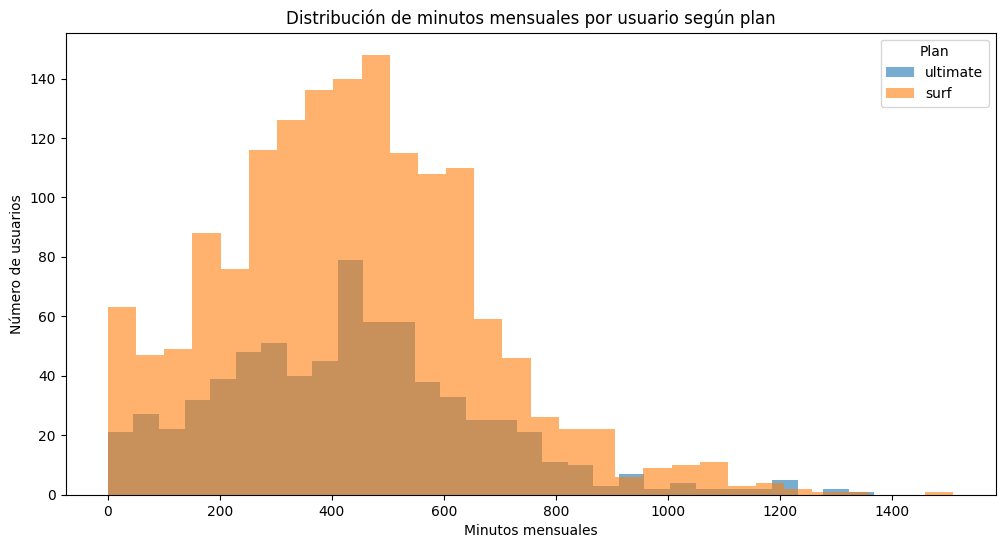

In [32]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
mean_duration_plan= user_calls_plan.groupby(['user_id','month','plan'])['duration'].sum().reset_index()
plt.figure(figsize=(12,6))
for plan in mean_duration_plan['plan'].unique():
    subset = mean_duration_plan[mean_duration_plan['plan'] == plan]
    plt.hist(subset['duration'], bins=30, alpha=0.6, label=plan)

plt.title('Distribución de minutos mensuales por usuario según plan')
plt.xlabel('Minutos mensuales')
plt.ylabel('Número de usuarios')
plt.legend(title='Plan')
plt.show()

In [33]:
# Calcula la media y la varianza de la duración mensual de llamadas.
media=user_calls_plan.groupby(['plan','month'])['duration'].mean().reset_index()
varianza = user_calls_plan.groupby('plan')['duration'].var().reset_index()
print(media)
print(varianza)

        plan  month  duration
0       surf    1.0  6.766667
1       surf    2.0  7.303279
2       surf    3.0  7.106742
3       surf    4.0  7.191899
4       surf    5.0  7.173700
5       surf    6.0  7.251863
6       surf    7.0  7.124836
7       surf    8.0  7.124718
8       surf    9.0  7.128537
9       surf   10.0  7.120604
10      surf   11.0  7.160421
11      surf   12.0  7.239358
12  ultimate    1.0  6.910714
13  ultimate    2.0  6.916667
14  ultimate    3.0  6.614130
15  ultimate    4.0  7.088176
16  ultimate    5.0  7.054491
17  ultimate    6.0  7.110522
18  ultimate    7.0  7.276061
19  ultimate    8.0  7.015709
20  ultimate    9.0  7.166857
21  ultimate   10.0  7.066706
22  ultimate   11.0  7.138889
23  ultimate   12.0  7.073878
       plan   duration
0      surf  35.502268
1  ultimate  35.332282


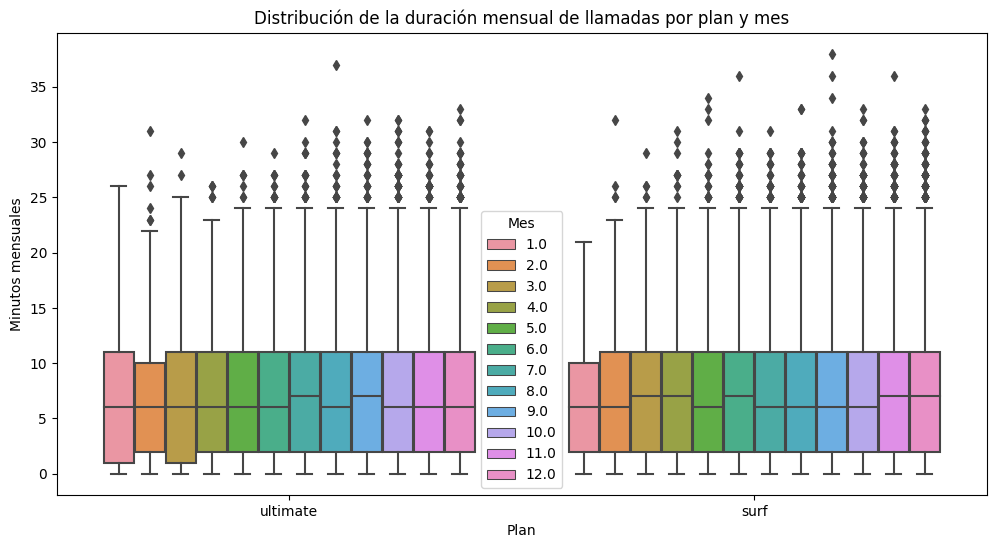

In [34]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
plt.figure(figsize=(12,6))
sns.boxplot(data=user_calls_plan, x='plan', y='duration', hue='month')

plt.title('Distribución de la duración mensual de llamadas por plan y mes')
plt.xlabel('Plan')
plt.ylabel('Minutos mensuales')
plt.legend(title='Mes')
plt.show()

#en conclusion a simple vista existen mas usuarios del plan surf y que en promedio cada mes tanto usuarios de surf como ultimate no suelen superar los 500 minutos de llamada

### Mensajes

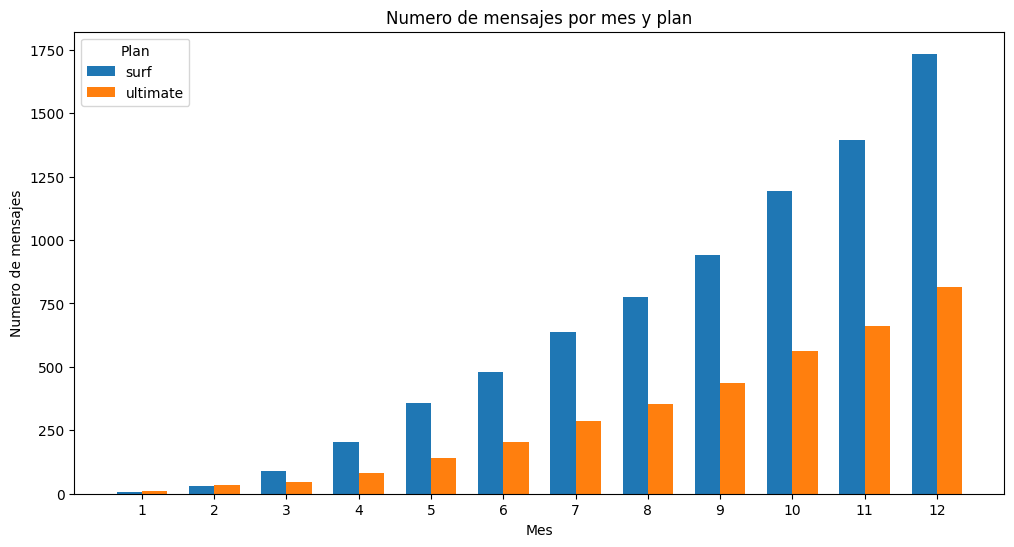

In [35]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
new_messages=messages[['user_id', 'id','message_date', 'month']]
user_message=user_calls_plan.merge(new_messages, on='user_id', how='left')
mean_duration_messages= user_calls_plan.groupby(['month','plan'])['id'].count()/12
mean_duration__messages_df = mean_duration_messages.reset_index()
months = mean_duration__messages_df['month'].unique()
plans = mean_duration__messages_df['plan'].unique()
x = np.arange(len(months))
width = 0.35
fig, ax = plt.subplots(figsize=(12,6))
for i, plan in enumerate(plans):
    plan_data = mean_duration__messages_df[mean_duration__messages_df['plan'] == plan]
    ax.bar(x + i*width, plan_data['id'], width, label=plan)
ax.set_title('Numero de mensajes por mes y plan')
ax.set_xlabel('Mes')
ax.set_ylabel('Numero de mensajes')
ax.set_xticks(x + width/2) 
ax.set_xticklabels(months.astype(int))
ax.legend(title='Plan')

plt.show()


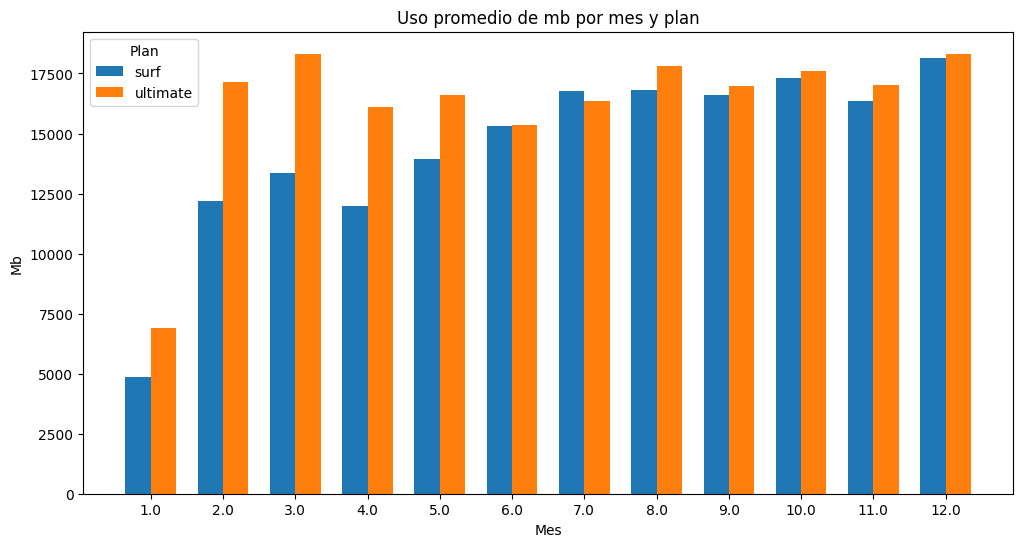

In [37]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
mean_mb = information.groupby(['month', 'plan'])['mb_used'].mean().reset_index()
months = sorted(mean_mb['month'].unique())
plans = mean_mb['plan'].unique()
x = np.arange(len(months))
width = 0.35
fig, ax = plt.subplots(figsize=(12,6))
for i, plan in enumerate(plans):
    plan_data = mean_mb[mean_mb['plan'] == plan]
    ax.bar(x + i*width, plan_data['mb_used'], width, label=plan)
ax.set_title('Uso promedio de mb por mes y plan')
ax.set_xlabel('Mes')
ax.set_ylabel('Mb')
ax.set_xticks(x + width/2) 
ax.set_xticklabels(months)
ax.legend(title='Plan')

plt.show()

### Internet

In [37]:
media=information.groupby(['month', 'plan'])['mb_used'].mean().reset_index()
print(media)


    month      plan       mb_used
0     1.0      surf   4874.860000
1     1.0  ultimate   6918.092500
2     2.0      surf  12178.843333
3     2.0  ultimate  17128.808571
4     3.0      surf  13345.440000
5     3.0  ultimate  18321.518333
6     4.0      surf  11984.203000
7     4.0  ultimate  16121.654762
8     5.0      surf  13936.354935
9     5.0  ultimate  16624.482414
10    6.0      surf  15301.529175
11    6.0  ultimate  15337.921064
12    7.0      surf  16783.600579
13    7.0  ultimate  16344.744407
14    8.0      surf  16795.331358
15    8.0  ultimate  17814.720141
16    9.0      surf  16591.431289
17    9.0  ultimate  16969.869535
18   10.0      surf  17311.335063
19   10.0  ultimate  17612.553396
20   11.0      surf  16339.254417
21   11.0  ultimate  17033.685354
22   12.0      surf  18132.469371
23   12.0  ultimate  18323.191854


In [38]:
varianza=information['mb_used'].var()

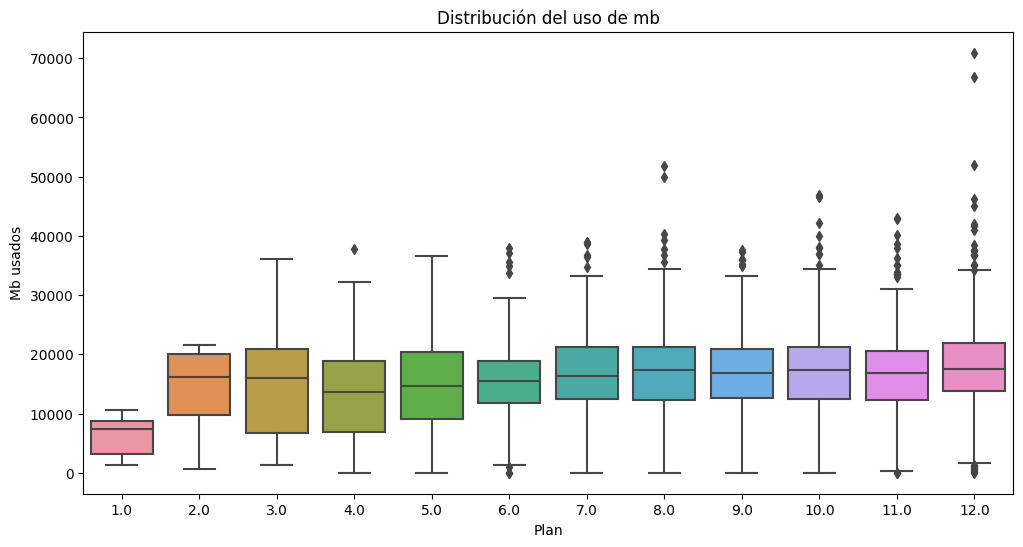

In [39]:
plt.figure(figsize=(12,6))
sns.boxplot(data=information, x='month', y='mb_used')

plt.title('Distribución del uso de mb')
plt.xlabel('Plan')
plt.ylabel('Mb usados')
plt.show()

## Ingreso

In [40]:
avg_payments = (
    information
    .groupby('plan_name')['total_monthly_revenue']
    .mean()
    .reset_index()
)

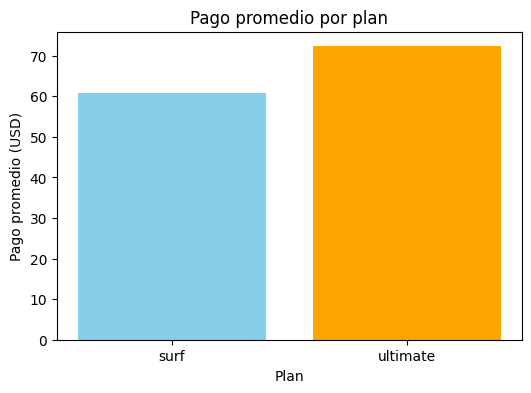

In [41]:
plt.figure(figsize=(6,4))
plt.bar(avg_payments['plan_name'], avg_payments['total_monthly_revenue'], color=['skyblue','orange'])
plt.title("Pago promedio por plan")
plt.xlabel("Plan")
plt.ylabel("Pago promedio (USD)")
plt.show()


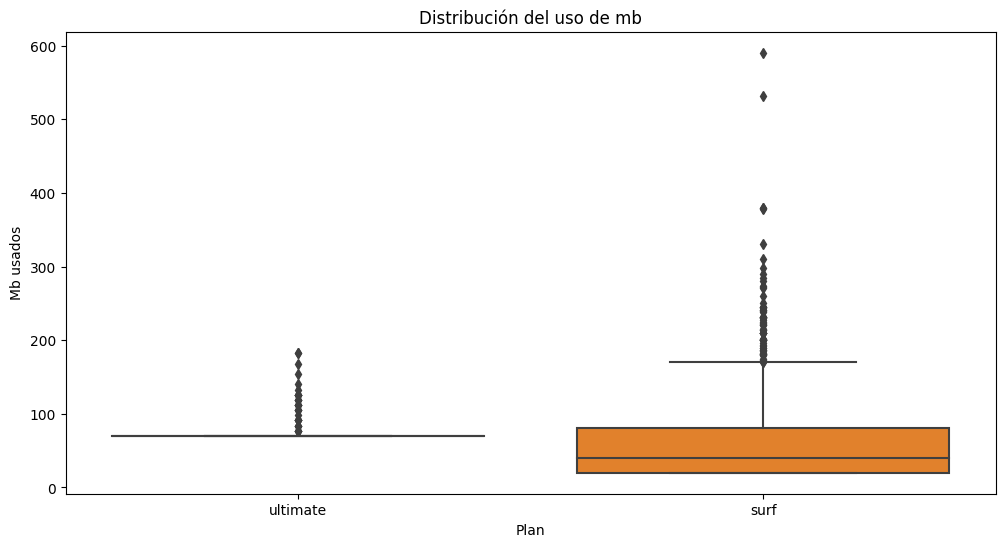

In [38]:
stats = (
    information
    .groupby('plan_name')['total_monthly_revenue']
    .agg(['mean', 'var'])
    .reset_index()
)
plt.figure(figsize=(12,6))
sns.boxplot(data=information, x='plan_name', y='total_monthly_revenue')

plt.title('Distribución del uso de mb')
plt.xlabel('Plan')
plt.ylabel('Mb usados')
plt.show()

## Prueba las hipótesis estadísticas

In [45]:

# Prueba las hipótesis
surf = information.loc[information['plan_name'] == 'surf', 'total_monthly_revenue']
ultimate = information.loc[information['plan_name'] == 'ultimate', 'total_monthly_revenue']

mean_surf = np.mean(surf)
mean_ultimate = np.mean(ultimate)
n_surf = len(surf)
n_ultimate = len(ultimate)

var_surf = np.var(surf, ddof=1)
var_ultimate = np.var(ultimate, ddof=1)

diff = mean_surf - mean_ultimate

se = np.sqrt(var_surf/n_surf + var_ultimate/n_ultimate)

z = 1.96

ci_low = diff - z*se
ci_high = diff + z*se

print("Diferencia de medias:", diff)
print("Intervalo de confianza 95%:", (ci_low, ci_high))

results = st.ttest_ind(surf, ultimate, equal_var=False)

print('Estadístico t:', results.statistic)
print('Valor p:', results.pvalue)

alpha = 0.05

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: las medias son diferentes.")
else:
    print("No podemos rechazar la hipótesis nula: no hay evidencia suficiente de diferencia.")



Diferencia de medias: -11.607480751571657
Intervalo de confianza 95%: (-14.462795295253486, -8.752166207889829)
Estadístico t: nan
Valor p: nan
No podemos rechazar la hipótesis nula: no hay evidencia suficiente de diferencia.


In [49]:
# Prueba las hipótesis
merged = information.merge(users[['user_id', 'city']], on='user_id', how='left')

print(merged['city'].unique())
ny_nj = merged.loc[merged['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA', 'total_monthly_revenue']
otras = merged.loc[merged['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA', 'total_monthly_revenue']
results = st.ttest_ind(ny_nj, otras, equal_var=False)

print('Estadístico t:', results.statistic)
print('Valor p:', results.pvalue)
alpha = 0.05

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: los ingresos son significativamente diferentes.")
else:
    print("No podemos rechazar la hipótesis nula: no hay evidencia de diferencia significativa.")
# no se si no busque bien pero creo que solo habia un usuario que me salia en esa region :(

['Atlanta-Sandy Springs-Roswell, GA MSA' 'Seattle-Tacoma-Bellevue, WA MSA'
 'Las Vegas-Henderson-Paradise, NV MSA' 'Tulsa, OK MSA'
 'Dallas-Fort Worth-Arlington, TX MSA'
 'San Francisco-Oakland-Berkeley, CA MSA' 'Grand Rapids-Kentwood, MI MSA'
 'Orlando-Kissimmee-Sanford, FL MSA'
 'San Jose-Sunnyvale-Santa Clara, CA MSA' 'Cleveland-Elyria, OH MSA'
 'Chicago-Naperville-Elgin, IL-IN-WI MSA' 'Knoxville, TN MSA'
 'New York-Newark-Jersey City, NY-NJ-PA MSA' 'Pittsburgh, PA MSA'
 'Fresno, CA MSA' 'Washington-Arlington-Alexandria, DC-VA-MD-WV MSA'
 'Indianapolis-Carmel-Anderson, IN MSA' 'Jacksonville, FL MSA'
 'Los Angeles-Long Beach-Anaheim, CA MSA'
 'Omaha-Council Bluffs, NE-IA MSA'
 'Houston-The Woodlands-Sugar Land, TX MSA'
 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA'
 'Tampa-St. Petersburg-Clearwater, FL MSA' 'Birmingham-Hoover, AL MSA'
 'Oklahoma City, OK MSA' 'Charlotte-Concord-Gastonia, NC-SC MSA'
 'Denver-Aurora-Lakewood, CO MSA'
 'Nashville-Davidson–Murfreesboro–Franklin, TN M

## Conclusión general


#se pudo obserbar como los usuarios de surf usaban mas sus paquetes, dentro de todo lo que mas observe en la parte me di cuento que en un incio yo pense que no habia mucho para enriquecer o corregir conforme fui avanzando note cosas que en un inicio pensaria que no era necesario resulto que si lo eran y tuve que regresar para ponerlo.